In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc
from joblib import Parallel, delayed

In [2]:
g_0=-3.0
g_n=-g_0
a=100
def potenc_un_united(g, a):
    return a*(-g**2+g**4)
n=6000
a_mat=np.zeros((n, n))
across_mat=np.zeros((n, n))
for i in range(1, n):
    a_mat[i][i-1]=np.sqrt(i)
for i in range(n-1):
    across_mat[i][i+1]=np.sqrt(i+1)

In [3]:
def get_eig_vals(norm_a, nenorm_a, pard, parf):
    suma=norm_a+nenorm_a
    razn=nenorm_a-norm_a
    suma2=np.dot(suma, suma)
    ham_fok=-np.dot(razn, razn)-pard*np.dot(suma, suma)+parf*np.dot(suma2, suma2)
    vals=np.linalg.eigvalsh(ham_fok)
    return vals[1]-vals[0]

In [4]:
list_a=np.arange(100, 3501, 100)

In [5]:
f=1
list_d=np.cbrt(4*(f**2)*list_a)

In [6]:
res=Parallel(n_jobs=6)(delayed(get_eig_vals)(a_mat, across_mat, i, f) for i in list_d)

In [7]:
list_energy=res.copy()

In [8]:
squares=[]
def for_square(g, a):
    return a*(-g**2+g**4)-a*(-(1/np.sqrt(2))**2+(1/np.sqrt(2))**4)
for i in list_a:
    squares.append(sc.integrate.quad(for_square, -0.707, 0.707, args=(i, ))[0])

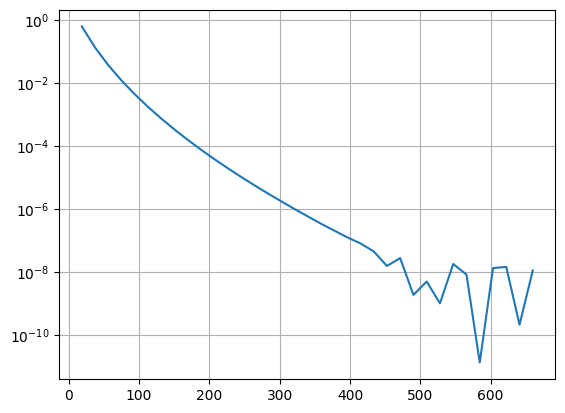

In [9]:
plt.grid(True)
plt.yscale('log')
plt.plot(np.abs(squares), list_energy)

In [10]:
print(squares)
print(list_energy)

[18.856180831478937, 37.712361662957875, 56.56854249443681, 75.42472332591575, 94.28090415739472, 113.13708498887362, 131.99326582035258, 150.8494466518315, 169.70562748331045, 188.56180831478943, 207.41798914626833, 226.27416997774725, 245.13035080922623, 263.98653164070515, 282.8427124721841, 301.698893303663, 320.555074135142, 339.4112549666209, 358.2674357980999, 377.12361662957886, 395.9797974610578, 414.83597829253665, 433.6921591240156, 452.5483399554945, 471.4045207869735, 490.26070161845246, 509.1168824499314, 527.9730632814103, 546.8292441128893, 565.6854249443682, 584.5416057758472, 603.397786607326, 622.253967438805, 641.110148270284, 659.9663291017629]
[np.float64(0.6103840571107018), np.float64(0.1300225573302889), np.float64(0.03589736063959492), np.float64(0.011706446652667069), np.float64(0.004284252022088708), np.float64(0.0017079278625971028), np.float64(0.0007277777375236383), np.float64(0.0003272579317012969), np.float64(0.00015387020543755625), np.float64(7.513794